Loan Approval Predictionn

In [49]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report,precision_score,roc_auc_score,roc_curve,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [50]:
df=pd.read_csv(r"C:\Users\kumma\Desktop\Bank_loan_approval\loan_approval_dataset.csv")

In [51]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [52]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [53]:
df.shape

(4269, 13)

In [54]:
df.drop(columns='loan_id',inplace=True)
print("loan_id removed")

loan_id removed


In [55]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0    no_of_dependents          4269 non-null   int64 
 1    education                 4269 non-null   object
 2    self_employed             4269 non-null   object
 3    income_annum              4269 non-null   int64 
 4    loan_amount               4269 non-null   int64 
 5    loan_term                 4269 non-null   int64 
 6    cibil_score               4269 non-null   int64 
 7    residential_assets_value  4269 non-null   int64 
 8    commercial_assets_value   4269 non-null   int64 
 9    luxury_assets_value       4269 non-null   int64 
 10   bank_asset_value          4269 non-null   int64 
 11   loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [58]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [59]:
negative_assets=df[df[' residential_assets_value']<0]
print(f"rows with negative assest value:{len(negative_assets)}")

df=df[df[" residential_assets_value"]>=0]
print(f"after remove negative assests in data:{df.shape}")

rows with negative assest value:28
after remove negative assests in data:(4241, 12)


<Axes: title={'center': 'Loan Approval Distribution'}>

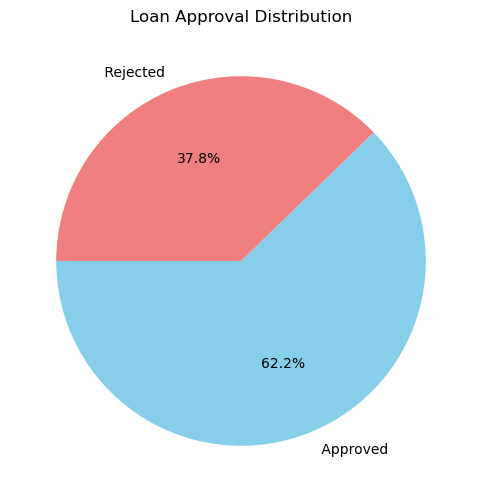

In [60]:
target_col = df[' loan_status'].value_counts()
# Simple pie chart
plt.title("Loan Approval Distribution")
target_col.plot.pie(
    autopct="%1.1f%%",   # show percentages
    figsize=(6,6),       # size of the chart
    startangle=180,       # rotate start angle
    labels=target_col.index,  # labels Approved/Rejected
    colors=["skyblue", "lightcoral"], # optional colors
    ylabel=''
)


In [61]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

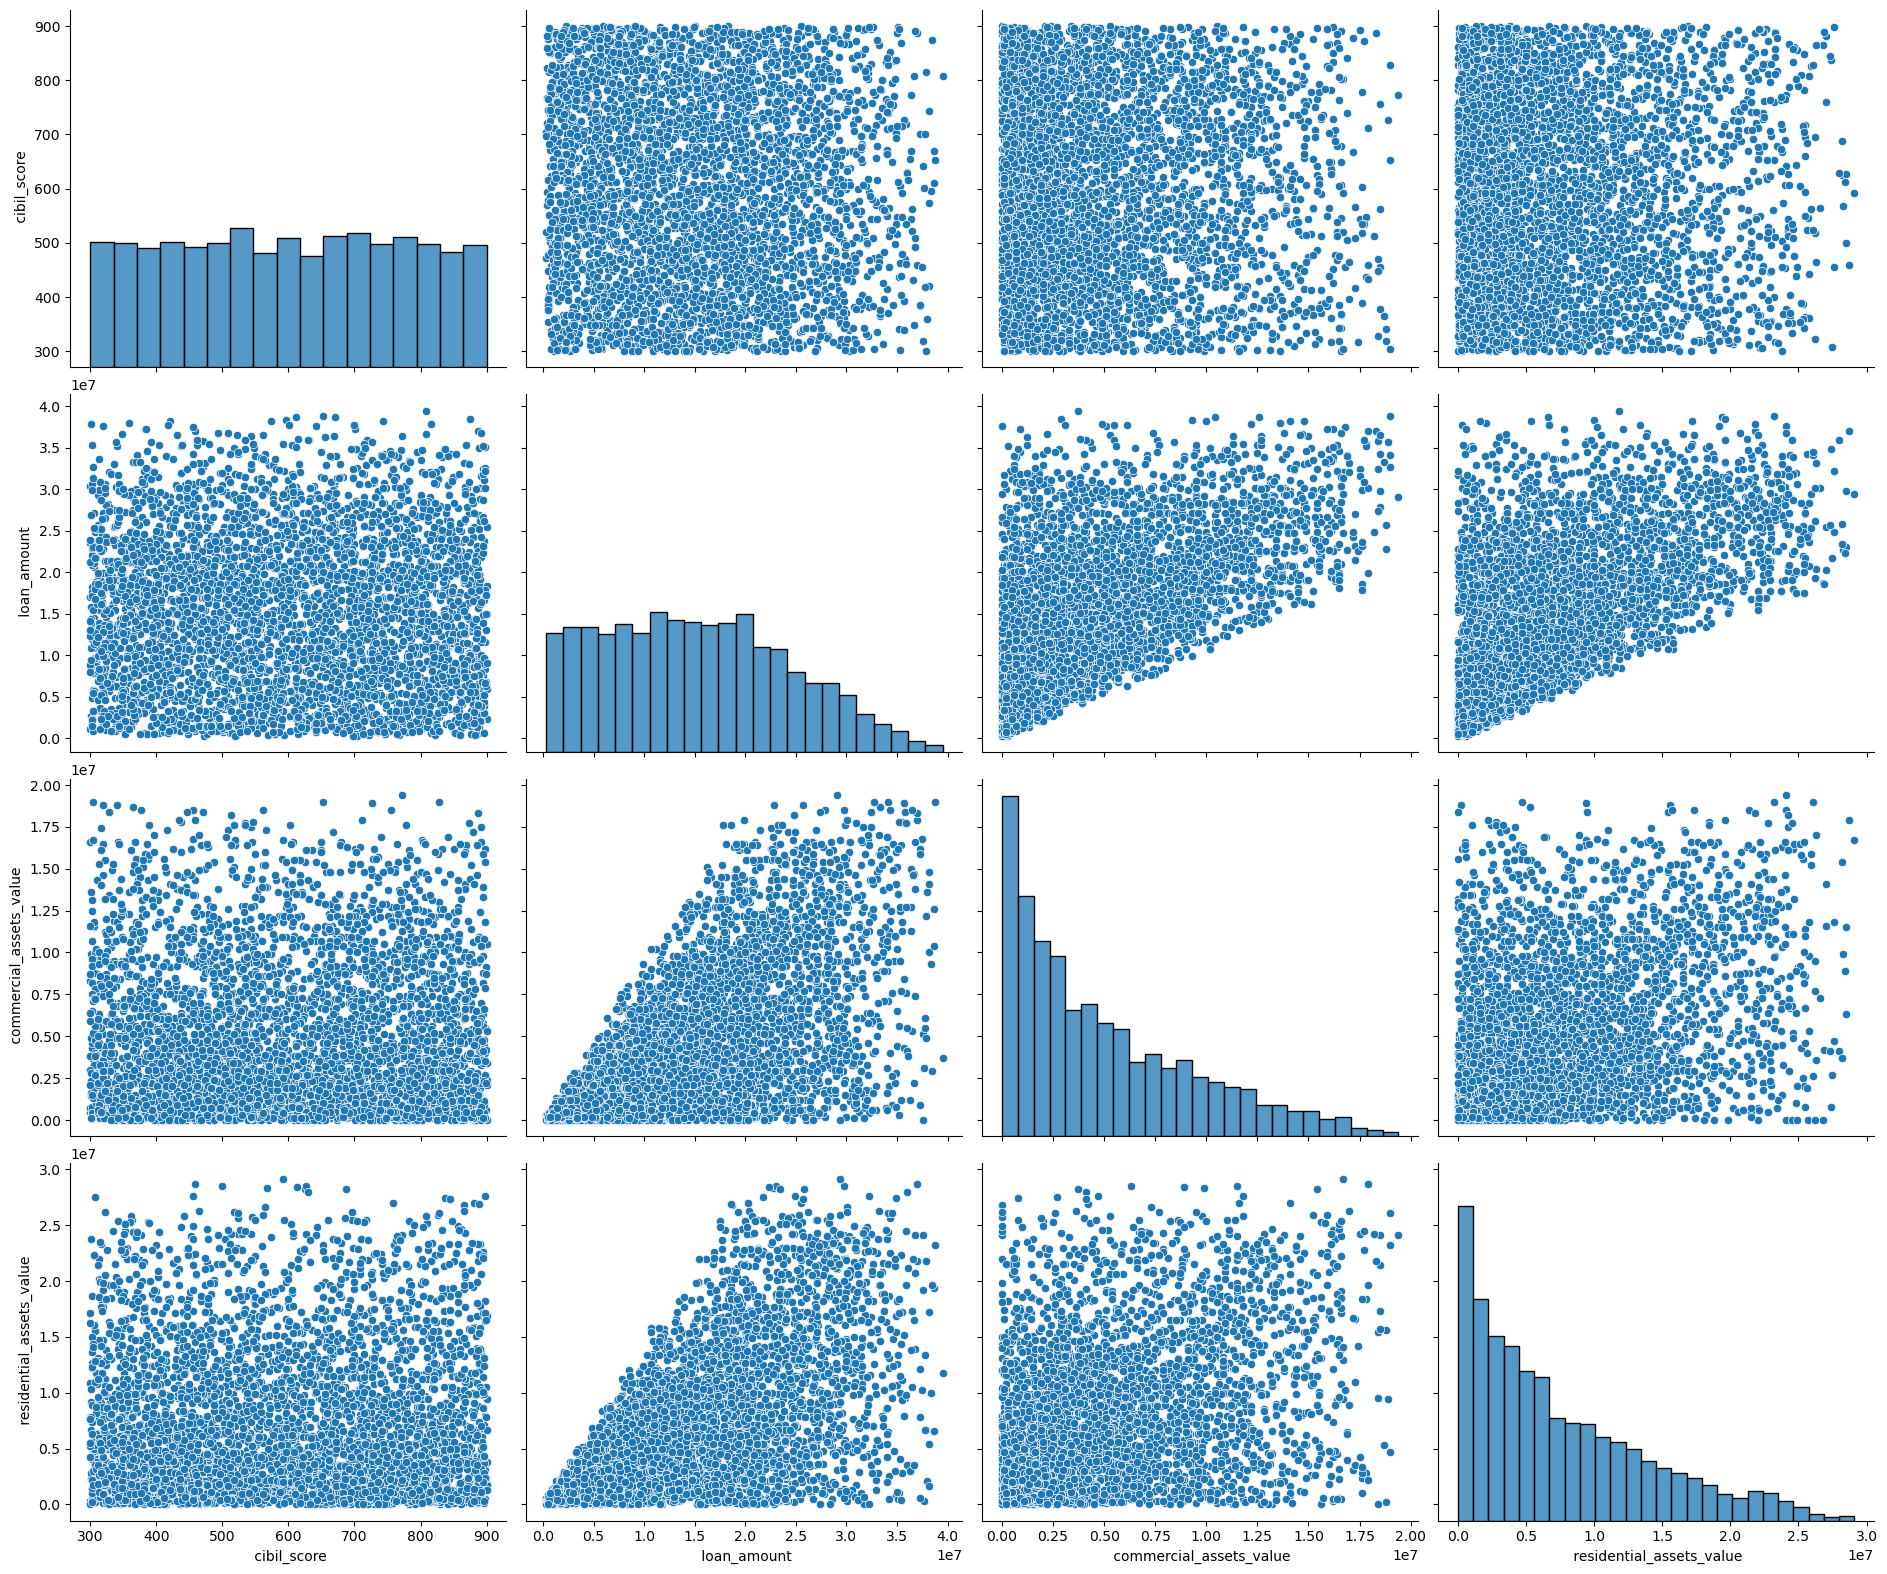

In [62]:
sns.pairplot(df[[' cibil_score', ' loan_amount', ' commercial_assets_value',' residential_assets_value']], 
             height=4, aspect=1.2)


In [63]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [64]:
# Strip spaces from all column names
df.columns = df.columns.str.strip()


<Axes: xlabel='cibil_score', ylabel='loan_amount'>

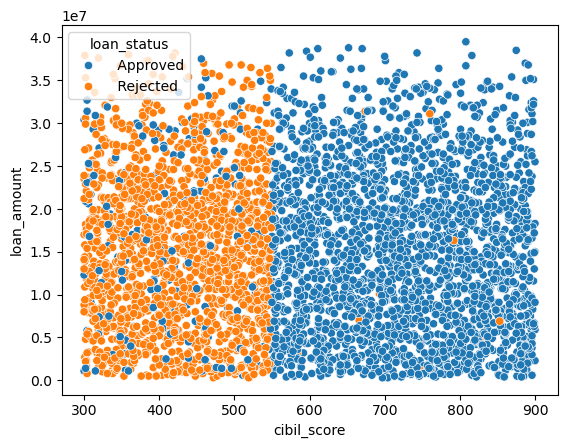

In [65]:
sns.scatterplot(x='cibil_score', y='loan_amount', 
                hue='loan_status', data=df)


In [66]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

<Axes: xlabel='education', ylabel='loan_amount'>

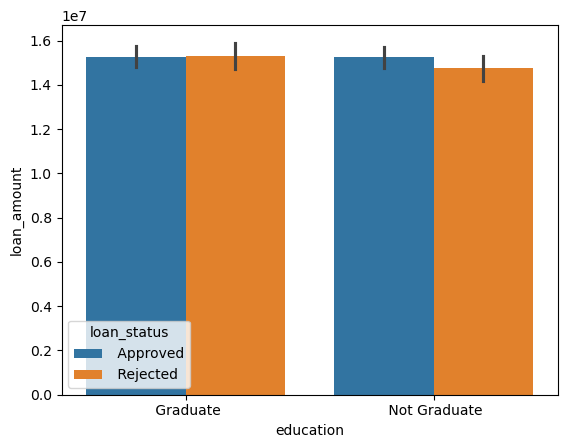

In [67]:
sns.barplot(x='education',y='loan_amount',hue='loan_status',data=df)

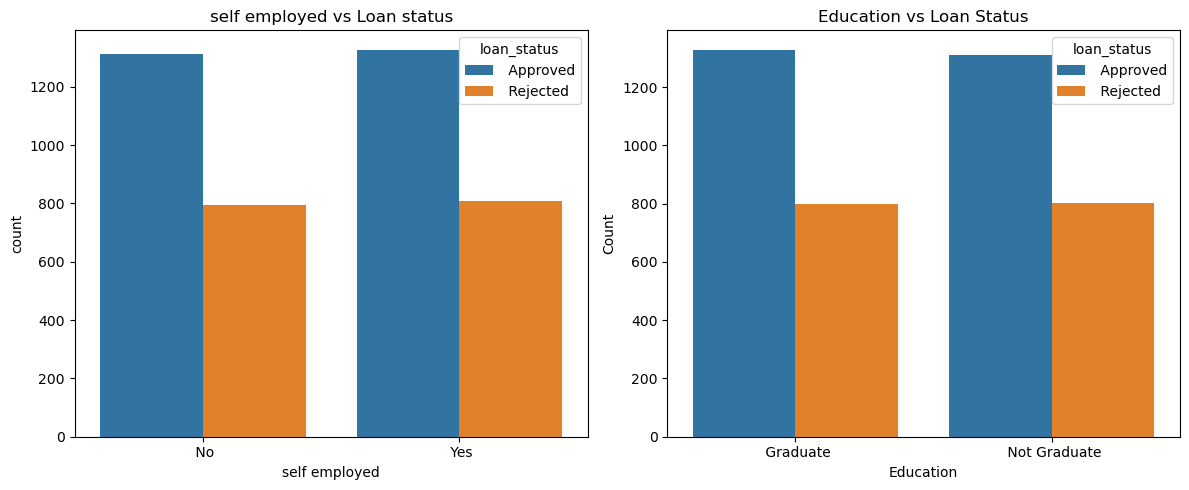

In [68]:
fig, axes=plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='self_employed', hue='loan_status',data=df, ax=axes[0])
axes[0].set_title("self employed vs Loan status")
axes[0].set_xlabel("self employed")
axes[0].set_ylabel("count")
sns.countplot(x='education', hue='loan_status', data=df, ax=axes[1])
axes[1].set_title("Education vs Loan Status")
axes[1].set_xlabel("Education")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [69]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

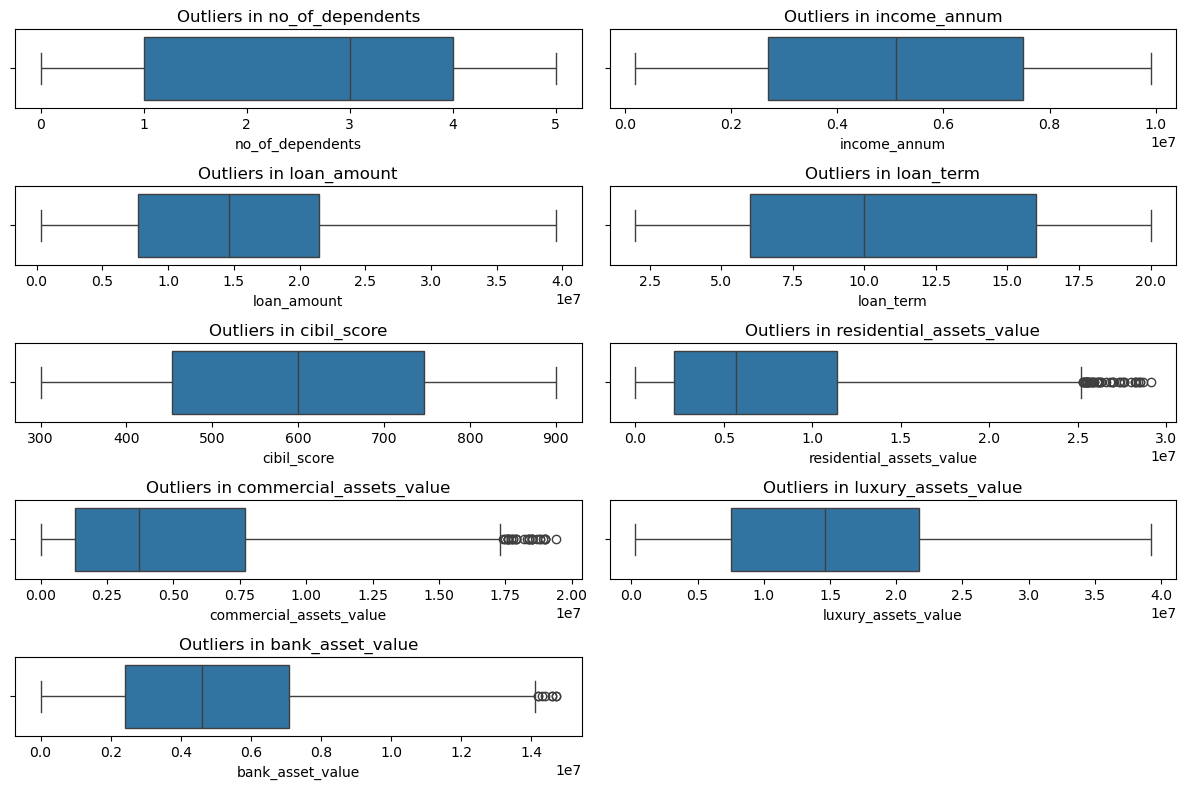

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//2+1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
plt.tight_layout()
plt.show()


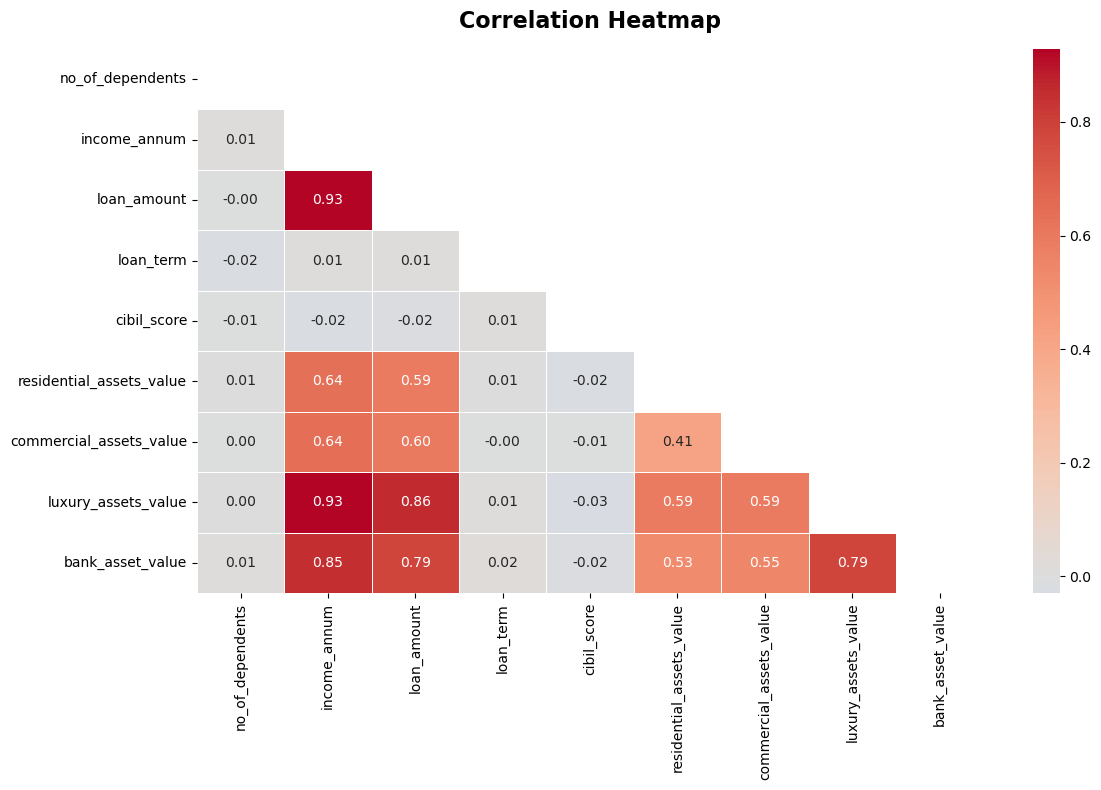

In [71]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            linecolor="white", ax=ax,
            annot_kws={"size": 10})

ax.set_title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [72]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [73]:
l=LabelEncoder()
df['education']=l.fit_transform(df['education'])

In [74]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,1,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,0,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,0,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,1,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [75]:
df['self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [76]:
l=LabelEncoder()
df['self_employed']=l.fit_transform(df['self_employed'])

In [77]:
# Strip spaces from values in loan_status column
df['loan_status'] = df['loan_status'].str.strip()


In [78]:
loan_order=[['Rejected','Approved']]
oe=OrdinalEncoder(categories=loan_order)
df['loan_status']=oe.fit_transform(df[['loan_status']]).astype(int)


In [79]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [80]:
X=df.drop(columns='loan_status')
y=df['loan_status']

In [81]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [82]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((3392, 11), (3392,), (849, 11), (849,))

In [83]:
df['loan_status'].value_counts()##now it ois not imbalanced dataset

loan_status
1    2640
0    1601
Name: count, dtype: int64

In [84]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: loan_status
1    2097
0    1295
Name: count, dtype: int64
After SMOTE: loan_status
1    2097
0    2097
Name: count, dtype: int64


In [85]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_res)
X_test_scaled=scaler.transform(X_test)

In [86]:
models={
    'LogisticRegression':LogisticRegression(random_state=42),
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier':RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier':GradientBoostingClassifier(random_state=42),
    'AdaBoostClassifier': AdaBoostClassifier(random_state=42)
}
results={}

for name, model in models.items():
    model.fit(X_train_scaled,y_train_res)
    y_pred=model.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_pred)
    cv=cross_val_score(model,X_train_scaled,y_train_res,cv=StratifiedKFold(n_splits=5),scoring='accuracy')
    results[name]={
        "model":model,
        "test_acc":acc,
        "cv_mean":cv.mean(),
        "cv_std":cv.std(),
        "y_pred":y_pred
    }
    print(f"{name}   Test:{acc}   cv:{cv.mean()}--{cv.std()}")

LogisticRegression   Test:0.9328621908127208   cv:0.9291914741097056--0.018303746706388305
DecisionTreeClassifier   Test:0.9787985865724381   cv:0.9816428240233714--0.009491253521934542
RandomForestClassifier   Test:0.9823321554770318   cv:0.9780665697599996--0.008240438767003382
GradientBoostingClassifier   Test:0.9846878680800942   cv:0.9797340850711581--0.004823158985339383
AdaBoostClassifier   Test:0.9599528857479388   cv:0.9632847946612202--0.009266789809676542


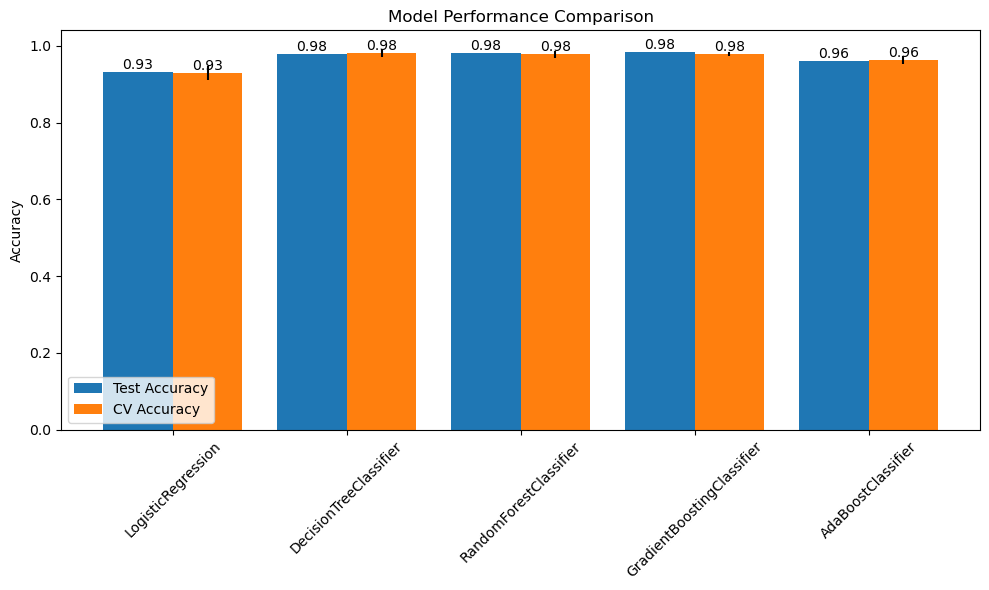

In [87]:
import matplotlib.pyplot as plt

# Extract metrics
model_names = list(results.keys())
test_accs   = [results[m]["test_acc"] for m in model_names]
cv_means    = [results[m]["cv_mean"] for m in model_names]
cv_stds     = [results[m]["cv_std"] for m in model_names]

x = range(len(model_names))
plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x, test_accs, width=0.4, label="Test Accuracy", align="center")
bars2 = plt.bar([i+0.4 for i in x], cv_means, width=0.4, yerr=cv_stds, label="CV Accuracy", align="center")

# Add values on top of bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

plt.xticks([i+0.2 for i in x], model_names, rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [88]:
best_name = max(results, key=lambda n: results[n]["test_acc"])
best = results[best_name]
best_model = best["model"]

print(f"Best Model : {best_name}")
print(f"Test Acc   : {best['test_acc']:.4f}")
print(f"CV Mean    : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")


Best Model : GradientBoostingClassifier
Test Acc   : 0.9847
CV Mean    : 0.9797 ± 0.0048


In [89]:
print(f"classification_report-{best_name}")
classification_report=classification_report(y_test,best["y_pred"])
print(classification_report)

classification_report-GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       306
           1       0.99      0.98      0.99       543

    accuracy                           0.98       849
   macro avg       0.98      0.99      0.98       849
weighted avg       0.98      0.98      0.98       849



<Axes: >

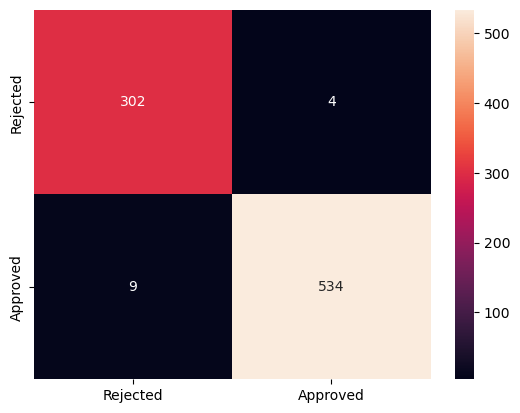

In [90]:
cm=confusion_matrix(y_test,best['y_pred'])
sns.heatmap(cm,annot=True,fmt='d',xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"],)

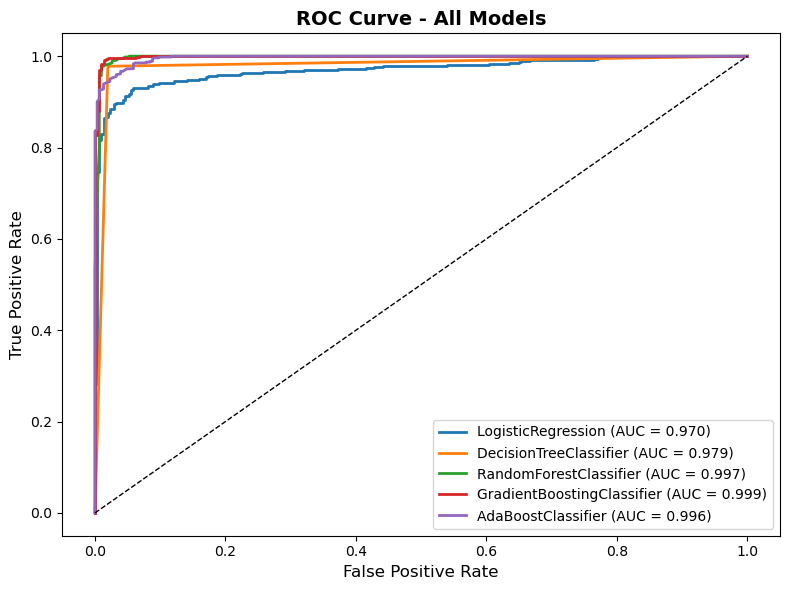

In [91]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    if hasattr(res["model"], "predict_proba"):
        y_prob = res["model"].predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [92]:
sample_applicants = pd.DataFrame({
    "no_of_dependents"        : [0, 2, 4, 1, 3],
    "education"               : [1, 1, 0, 0, 1],
    "self_employed"           : [0, 0, 1, 0, 1],
    "income_annum"            : [9000000, 5500000, 2000000, 7500000, 3200000],
    "loan_amount"             : [5000000, 12000000, 20000000, 8000000, 15000000],
    "loan_term"               : [8, 12, 20, 6, 16],
    "cibil_score"             : [800, 650, 400, 750, 500],
    "residential_assets_value": [15000000, 8000000, 1000000, 12000000, 3000000],
    "commercial_assets_value" : [10000000, 4000000, 500000, 7000000, 1000000],
    "luxury_assets_value"     : [20000000, 9000000, 2000000, 14000000, 4000000],
    "bank_asset_value"        : [8000000, 3000000, 500000, 6000000, 1500000]
})

applicant_names = [
    "Applicant A - High Income",
    "Applicant B - Average Profile",
    "Applicant C - Low Income",
    "Applicant D - Good Credit",
    "Applicant E - High Risk"
]

print("Sample applicants created.")
sample_applicants

Sample applicants created.


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,0,1,0,9000000,5000000,8,800,15000000,10000000,20000000,8000000
1,2,1,0,5500000,12000000,12,650,8000000,4000000,9000000,3000000
2,4,0,1,2000000,20000000,20,400,1000000,500000,2000000,500000
3,1,0,0,7500000,8000000,6,750,12000000,7000000,14000000,6000000
4,3,1,1,3200000,15000000,16,500,3000000,1000000,4000000,1500000


In [93]:
# Use the sample applicants DataFrame for prediction
X_test_scaled = scaler.transform(sample_applicants)   # assuming you fitted a scaler earlier

# Get predictions from the best model
best_model = results["GradientBoostingClassifier"]["model"]
predictions = best_model.predict(X_test_scaled)

# Map numeric predictions to labels
labels = ["Rejected" if p == 0 else "Approved" for p in predictions]

# Build results DataFrame safely
results_df = pd.DataFrame({
    "Applicant": applicant_names,   # 5 names
    "Prediction": predictions,      # 5 predictions
    "Decision": labels              # 5 labels
})

print(results_df)


                       Applicant  Prediction  Decision
0      Applicant A - High Income           1  Approved
1  Applicant B - Average Profile           1  Approved
2       Applicant C - Low Income           0  Rejected
3      Applicant D - Good Credit           1  Approved
4        Applicant E - High Risk           0  Rejected


In [94]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GradientBoostingClassifier(random_state=42))
])

pipeline.fit(X_train_res, y_train_res)

import joblib
joblib.dump(pipeline, "best_model.pkl")


['best_model.pkl']

In [95]:
print("Training columns:", X_train.columns.tolist())
print("Sample applicant columns:", sample_applicants.columns.tolist())


Training columns: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Sample applicant columns: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
